[2026-04-24 16:41:18 | +0.0s] ファイル検索開始
[2026-04-24 16:41:18 | +0.0s] 対象ファイル数: 3
[2026-04-24 16:41:18 | +0.0s] 処理中 (1/3): change_point_pairs_pelt_rbf_20260418_102306.csv
[2026-04-24 16:41:18 | +0.2s] 読み込み行数: 609
[2026-04-24 16:41:18 | +0.4s] datetime有効行数: 609 / 609
[2026-04-24 16:41:18 | +0.4s] 集計日数: 94


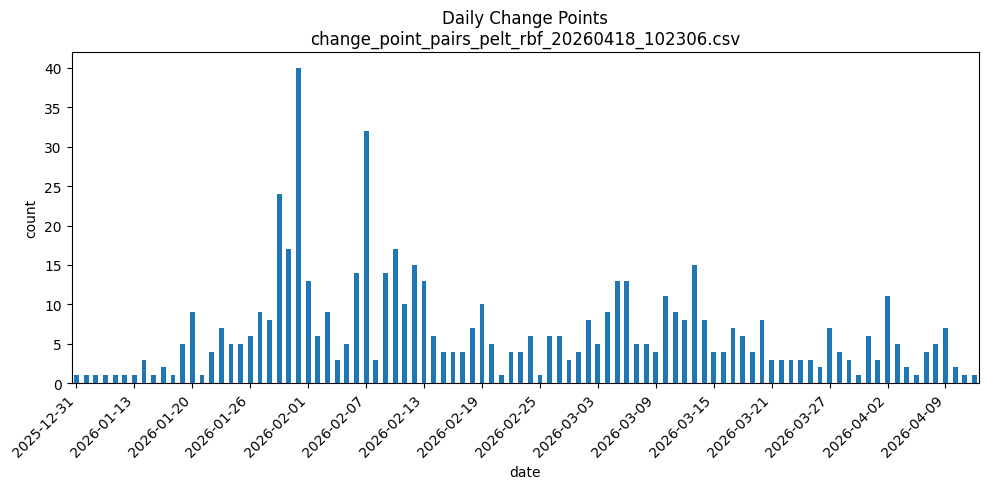

[2026-04-24 16:41:20 | +2.3s] 処理中 (2/3): change_point_pairs_pelt_l2_20260423_080337.csv
[2026-04-24 16:41:20 | +2.5s] 読み込み行数: 6364
[2026-04-24 16:41:20 | +2.5s] datetime有効行数: 6364 / 6364
[2026-04-24 16:41:20 | +2.5s] 集計日数: 111


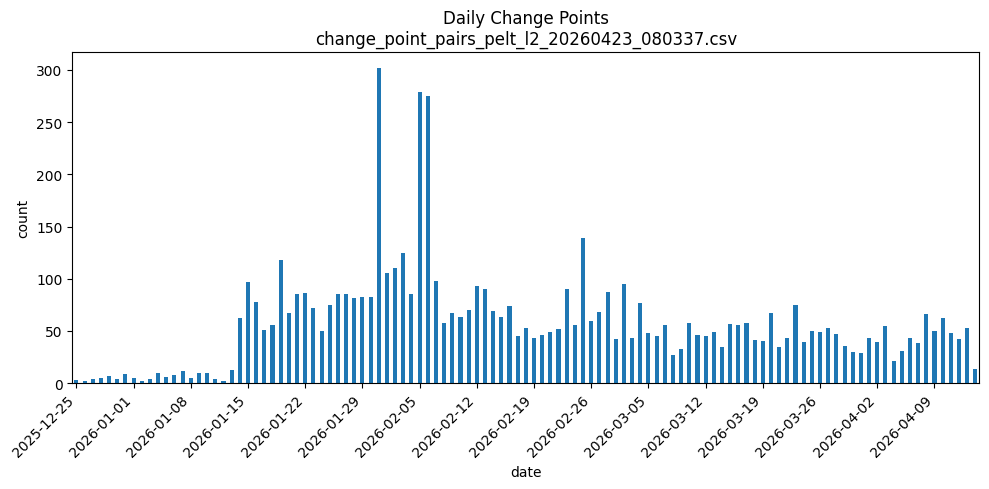

[2026-04-24 16:41:22 | +3.9s] 処理中 (3/3): change_point_pairs_Binseg_l1_20260424_163322.csv
[2026-04-24 16:41:22 | +4.0s] 読み込み行数: 7343
[2026-04-24 16:41:22 | +4.0s] datetime有効行数: 7343 / 7343
[2026-04-24 16:41:22 | +4.0s] 集計日数: 111


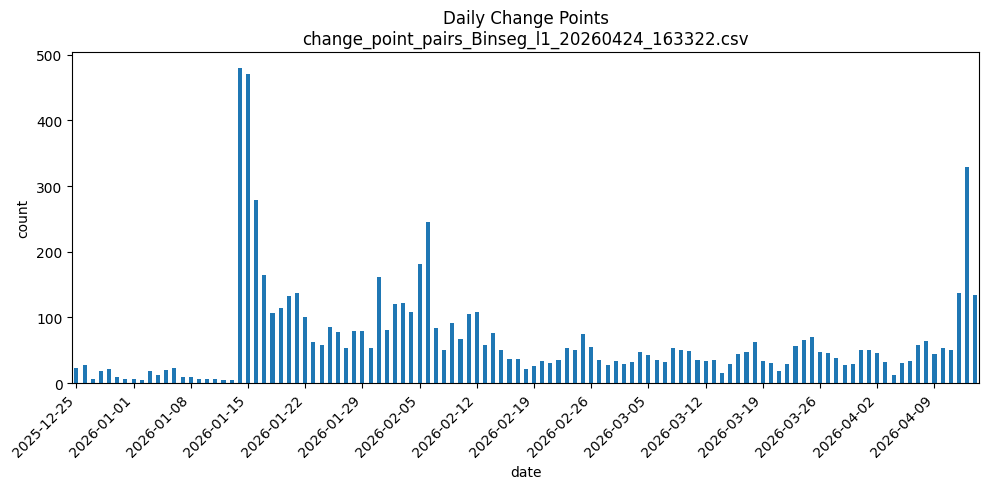

[2026-04-24 16:41:23 | +5.0s] 完了


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# =========================================
# 0. パラメータ
# =========================================
FILE_PATTERN = "change_point_pairs_*.csv"

# 横軸ラベルの最大表示数
MAX_LABELS = 15

# 図サイズ
FIGSIZE = (10, 5)

# =========================================
# 1. ログ関数
# =========================================
START_TIME = datetime.now()

def log(msg):
    now = datetime.now()
    elapsed = (now - START_TIME).total_seconds()
    print(f"[{now.strftime('%Y-%m-%d %H:%M:%S')} | +{elapsed:.1f}s] {msg}")

# =========================================
# 2. ファイル検索
# =========================================
log("ファイル検索開始")

current_dir = Path(".")
files = list(current_dir.glob(FILE_PATTERN))

if not files:
    raise FileNotFoundError(f"対象ファイルが見つかりません: {FILE_PATTERN}")

# 更新日時順にソート
files = sorted(files, key=lambda f: f.stat().st_mtime)

log(f"対象ファイル数: {len(files)}")

# =========================================
# 3. ファイルごとに読み込み・集計・描画
# =========================================
for i, file_path in enumerate(files, start=1):
    log(f"処理中 ({i}/{len(files)}): {file_path.name}")

    # -------------------------
    # CSV読み込み
    # -------------------------
    try:
        df = pd.read_csv(
            file_path,
            skiprows=1,
            names=["coin", "datetime", "score"]
        )
    except Exception as e:
        log(f"読み込み失敗: {file_path.name} | {e}")
        continue

    log(f"読み込み行数: {len(df)}")

    # -------------------------
    # datetime変換
    # -------------------------
    df["datetime"] = pd.to_datetime(
        df["datetime"],
        format="%Y-%m-%d %H:%M:%S",
        errors="coerce"
    )

    before = len(df)
    df = df.dropna(subset=["datetime"])
    after = len(df)

    log(f"datetime有効行数: {after} / {before}")

    if df.empty:
        log(f"スキップ: 有効な日時データなし | {file_path.name}")
        continue

    # -------------------------
    # 日付単位で集計
    # -------------------------
    df["date"] = df["datetime"].dt.date
    daily_counts = df.groupby("date").size().sort_index()

    if daily_counts.empty:
        log(f"スキップ: 集計結果が空 | {file_path.name}")
        continue

    log(f"集計日数: {len(daily_counts)}")

    # -------------------------
    # プロット
    # -------------------------
    fig, ax = plt.subplots(figsize=FIGSIZE)

    daily_counts.plot(kind="bar", ax=ax)

    ax.set_xlabel("date")
    ax.set_ylabel("count")
    ax.set_title(f"Daily Change Points\n{file_path.name}")

    # -------------------------
    # 横軸ラベルを自動で間引く
    # -------------------------
    n = len(daily_counts)
    step = max(1, n // MAX_LABELS)

    ticks = ax.get_xticks()
    labels = [label.get_text() for label in ax.get_xticklabels()]

    ax.set_xticks(ticks[::step])
    ax.set_xticklabels(labels[::step], rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

log("完了")